In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [4]:
X,y_true=make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)
df=pd.DataFrame(X,columns=['Feature_1','Feature_2'])
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [6]:
inertia=[]
K_range=range(1,11)

In [7]:
for k in K_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [8]:
inertia

[1000.0000000000001,
 297.89541410517216,
 11.575484723104978,
 9.752067977356841,
 8.257175272446283,
 6.9175773204167985,
 6.334755391595287,
 5.70417717790143,
 5.060234133532076,
 4.762361898130397]

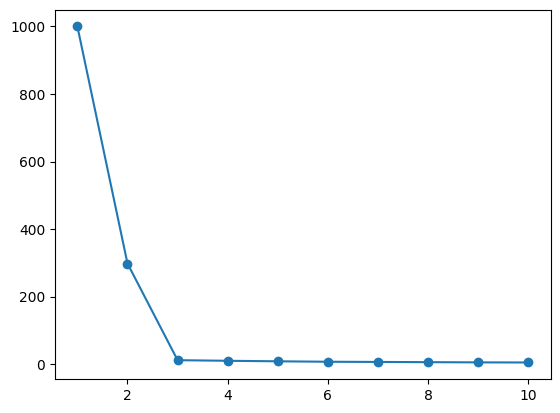

In [9]:
plt.plot(K_range,inertia,marker='o')

In [10]:
kmeans_final=KMeans(n_clusters=3,random_state=42)

In [11]:
cluster_labels=kmeans_final.fit_predict(X_scaled)

In [12]:
df['clusters']=cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

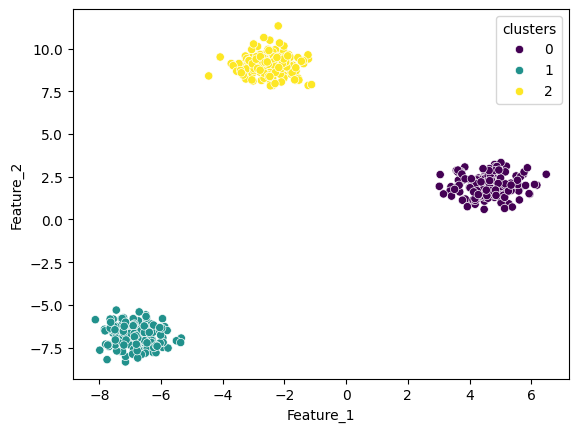

In [14]:
sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['clusters'],
    palette='viridis'
)